# Lecture 10 (live demo) — The price of a principle

**AI-integrated Sustainable Finance (25881) · Lecture 10 live demo**

---

Every sustainable-investing rule is a constraint, and every constraint has a price. In this demo we price
the six funds you built in Lab 9b, ask an optimiser to buy the same ESG scores more cheaply, and test whether
ESG is special or whether *any* constraint would cost this much.

There are three **Predict first** questions. Write your guess in the variable at the top of the cell
*before* you run it.

### How to read this notebook

* **Narrative track**: the prose and the code.
* **Maths track**: the collapsible grey boxes. Open them if you want the derivation; skip them if you do not.

> **Data.** The same 349 S&P 500 stocks as the slides: Sustainalytics-style ESG *risk* ratings (lower is
> better), early-2018 market caps, and five years of daily prices (Feb 2013 – Feb 2018). The ratings are a
> later snapshot than the prices. That is fine for pricing constraints, which are statements about risk; it is
> **not** evidence about whether ESG earns returns.

## 1. Load the universe

In [1]:
import numpy as np
import pandas as pd
import esgprice as ep

uni = ep.load_universe()
print(f"Benchmark ESG risk: {uni.b @ uni.r:.2f} | Ledoit-Wolf shrinkage intensity: {uni.shrinkage:.3f}")

sp500_esg.csv: local clone (data\sp500_esg.csv)
constituents-financials.csv: local clone (data\constituents-financials.csv)
all_stocks_5yr.csv: local clone (data\all_stocks_5yr.csv)

349 stocks with ESG ratings, market caps and complete prices (2013-02-11 to 2018-02-07, 1258 daily returns); 19 rated names dropped for missing prices.
Benchmark ESG risk: 23.03 | Ledoit-Wolf shrinkage intensity: 0.018


<details><summary><b>Maths: the three currencies we price rules in</b></summary>

* **Tracking error**: $\mathrm{TE}(w) = \sqrt{(w-b)^{\top}\Sigma\,(w-b)}$, where $b$ is the cap-weighted benchmark
  and $\Sigma$ the annualised covariance (Ledoit–Wolf shrinkage).
* **Relative Sharpe ratio**: with no return forecast we trust, let the benchmark be efficient, so expected
  excess returns are $\mu = \delta\,\Sigma b$. Then $\mathrm{SR}(w)/\mathrm{SR}(b) = \rho(w,b)$, the correlation
  with the benchmark. The unknown $\delta$ cancels.
* **Diversification**: effective holdings $1/\sum_i w_i^2$, and sector weights.
</details>

## 2. Six reasonable rules, six different bills

The six Lab 9b screens, rebuilt on the 349 priced stocks. Compare each fund's ESG risk with what it pays in
tracking error and in diversification.

In [2]:
funds = ep.screens(uni)
table = ep.profiles(uni, funds).loc[ep.FUND_ORDER]
table.round({"ESG risk": 2, "TE (%)": 2, "Sharpe / benchmark": 3, "effective holdings": 0, "technology (%)": 1})

,holdings,ESG risk,TE (%),Sharpe / benchmark,effective holdings,technology (%)
Benchmark,349.0,23.03,0.00,1.000,93.0,17.1
Exclusion,318.0,21.72,0.93,0.997,80.0,19.1
Controversy screen,263.0,20.21,2.57,0.979,136.0,17.6
Best-in-class,173.0,17.33,2.30,0.983,54.0,23.3
ESG tilt,349.0,17.41,2.01,0.987,62.0,31.8
Leaders only,145.0,15.77,3.19,0.970,33.0,42.2


### Predict first (1)

How much tracking error does it take to cut the portfolio's ESG risk by 20%, if an optimiser chooses the
weights? Write your guess (in % a year) in `MY_GUESS_Q1`, then run the cell.

In [3]:
MY_GUESS_Q1 = 2.0     # your guess, % a year

w20, lam20 = ep.min_te(uni, ep.cut_target(uni, 0.20))
p20 = ep.profile(uni, w20)
print(f"Your guess: {MY_GUESS_Q1:.2f}%  |  the optimiser: {p20['TE (%)']:.2f}% "
      f"for ESG risk {p20['ESG risk']:.2f} (benchmark {uni.b @ uni.r:.2f})")

Your guess: 2.00%  |  the optimiser: 0.79% for ESG risk 18.42 (benchmark 23.03)


### Predict first (2)

The exclusion fund paid **0.93%** tracking error to bring ESG risk to 21.72. What would an optimiser pay for
exactly the same ESG risk? Guess, then run. The cell repeats the question for every fund.

In [4]:
MY_GUESS_Q2 = 0.5     # your guess for the exclusion fund, % a year

rows = []
for k in ep.FUND_ORDER[1:]:
    p = ep.profile(uni, funds[k].values)
    w_opt, _ = ep.min_te(uni, p["ESG risk"])
    q = ep.profile(uni, w_opt)
    rows.append({"fund": k, "ESG risk": p["ESG risk"], "screen TE (%)": p["TE (%)"],
                 "optimiser TE (%)": q["TE (%)"], "optimiser / screen": q["TE (%)"] / p["TE (%)"],
                 "screen eff. holdings": p["effective holdings"], "optimiser eff. holdings": q["effective holdings"]})
same_esg = pd.DataFrame(rows).set_index("fund")
print(f"Your guess for the exclusion fund: {MY_GUESS_Q2:.2f}%")
same_esg.round(2)

Your guess for the exclusion fund: 0.50%


,ESG risk,screen TE (%),optimiser TE (%),optimiser / screen,screen eff. holdings,optimiser eff. holdings
fund,,,,,,
Exclusion,21.72,0.93,0.18,0.20,80.20,92.61
Controversy screen,20.21,2.57,0.43,0.17,135.53,88.09
Best-in-class,17.33,2.30,1.06,0.46,53.83,71.16
ESG tilt,17.41,2.01,1.04,0.52,62.38,71.74
Leaders only,15.77,3.19,1.54,0.48,32.75,59.34


**Every screen pays more than it needs to.** The optimiser buys each fund's ESG score at a fraction of the
tracking error, and keeps more of the benchmark's diversification. Screens are blunt; the optimiser is told
the price of every stock it drops.

## 3. The frontier and the price curve

Forty optimisations, from the benchmark's ESG level down to near the lowest attainable. This takes a few
seconds.

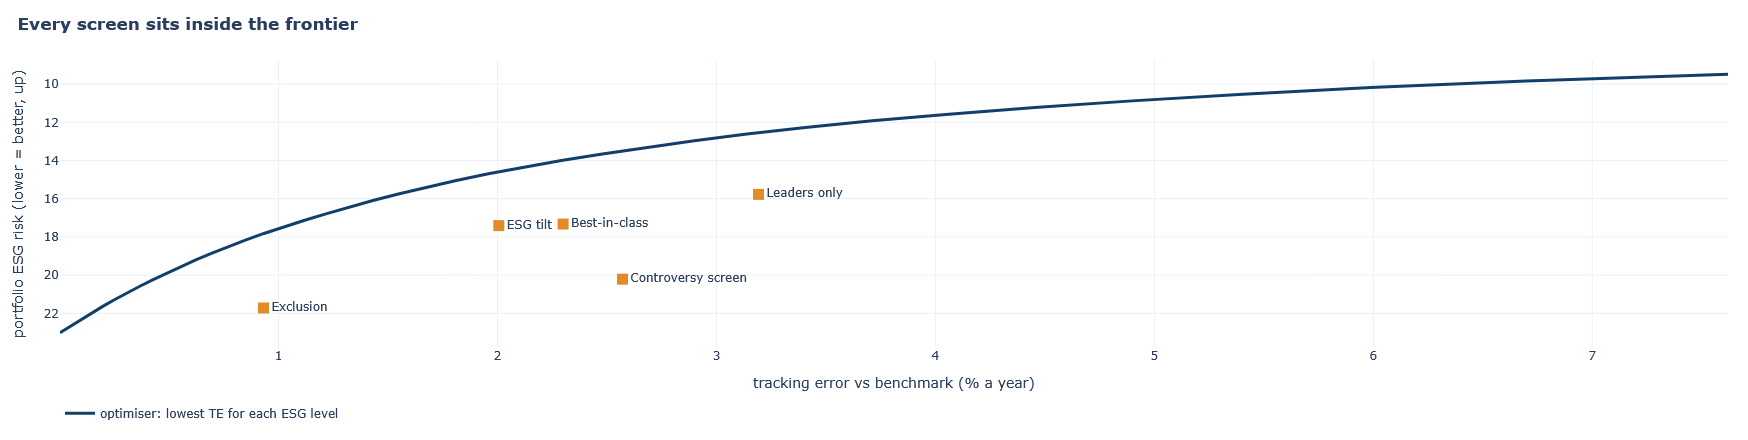

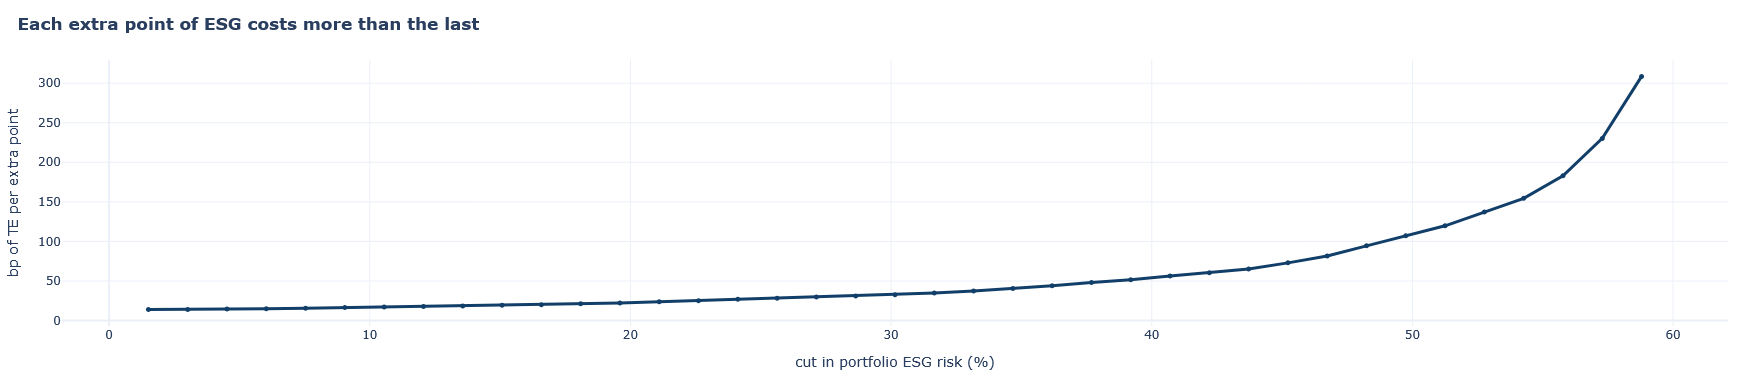

Marginal price near the benchmark: 14 bp per point; at the extreme: 308 bp per point


In [5]:
fr = ep.frontier(uni)
ep.fig_frontier(uni, fr, funds).show()
ep.fig_price_curve(fr, uni.b @ uni.r).show()
print(f"Marginal price near the benchmark: {fr['marginal TE per point (bp)'].iloc[1]:.0f} bp per point; "
      f"at the extreme: {fr['marginal TE per point (bp)'].iloc[-1]:.0f} bp per point")

## 4. Your turn: move the target

Drag the slider to choose the cut in ESG risk. The optimiser re-solves each time. If sliders are unavailable,
change `TARGET_CUT` and run the cell again.

In [6]:
TARGET_CUT = 0.20      # used when ipywidgets is not available

def show_target(cut=TARGET_CUT):
    w, lam = ep.min_te(uni, ep.cut_target(uni, cut))
    if w is None:
        print("Infeasible: no long-only portfolio reaches that ESG level.")
        return
    p = ep.profile(uni, w)
    print(f"cut {cut:.0%}: ESG risk {p['ESG risk']:.2f} | TE {p['TE (%)']:.2f}% | "
          f"Sharpe/benchmark {p['Sharpe / benchmark']:.3f} | effective holdings {p['effective holdings']:.0f} | "
          f"technology {p['technology (%)']:.1f}% | shadow price {lam:.2e}")
    ep.fig_sectors(uni, w, f"Sector weights after a {cut:.0%} cut").show()

try:
    import ipywidgets as widgets
    widgets.interact(show_target, cut=widgets.FloatSlider(value=TARGET_CUT, min=0.0, max=0.55, step=0.05,
                     description="cut", readout_format=".0%", continuous_update=False))
except ImportError:
    show_target(TARGET_CUT)

interactive(children=(FloatSlider(value=0.2, continuous_update=False, description='cut', max=0.55, readout_for…

## 5. Floor or penalty? The same problem twice

A **floor** guarantees the ESG level; a **penalty** guarantees the price. Solve the penalty version with
$\lambda$ set to the floor's shadow price, and compare.

<details><summary><b>Maths: why they coincide</b></summary>

The floor problem's stationarity condition, $2\Sigma(w^*-b) + \lambda^* s - \nu\mathbf{1} - \eta = 0$, is
exactly the penalty problem's condition when $\lambda = \lambda^*$. With $\Sigma$ positive definite the
solution is unique, so both problems return the same $w^*$. The envelope theorem gives
$\partial\,\mathrm{TE}^{2*}/\partial t = -\lambda^*$: the multiplier is the marginal price of the target.
</details>

In [7]:
w_pen = ep.penalty_portfolio(uni, lam20)
print(f"Floor:   ESG risk {w20 @ uni.r:.3f}, TE {100 * ep.tracking_error(uni, w20):.3f}%")
print(f"Penalty: ESG risk {w_pen @ uni.r:.3f}, TE {100 * ep.tracking_error(uni, w_pen):.3f}%  (lambda = {lam20:.3e})")
print(f"Largest weight difference between the two portfolios: {np.abs(w_pen - w20).max():.1e}")

Floor:   ESG risk 18.420, TE 0.790%
Penalty: ESG risk 18.420, TE 0.790%  (lambda = 3.581e-05)
Largest weight difference between the two portfolios: 3.3e-05


## 6. Predict first (3): is ESG special?

Shuffle the ESG scores between firms (the same numbers, attached to the wrong companies) and ask for the same
20% cut. Will it be **cheaper**, about the **same**, or **dearer** than with the real scores? Write your answer,
then run. We also shuffle *within* sectors, which keeps each sector's ESG profile intact.

Your guess: dearer
real scores 0.79% | shuffled across firms: mean 0.54%, cheaper in 100% | shuffled within sectors: mean 0.68%, cheaper in 100%


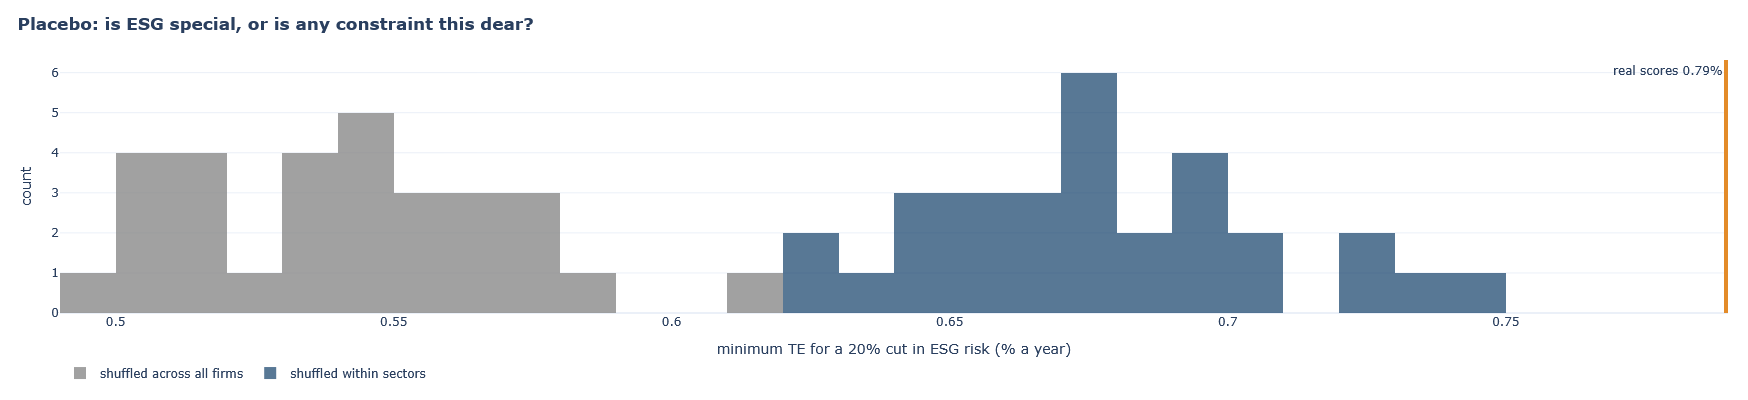

In [8]:
MY_GUESS_Q3 = "dearer"    # "cheaper", "same" or "dearer"
N_SHUFFLES = 30            # the slides used 300 shuffles of each kind (about 1.5 minutes)

full = ep.placebo(uni, n=N_SHUFFLES)
within = ep.placebo(uni, n=N_SHUFFLES, within_sector=True)
real = p20["TE (%)"]
print(f"Your guess: {MY_GUESS_Q3}")
print(f"real scores {real:.2f}% | shuffled across firms: mean {full.mean():.2f}%, cheaper in {np.mean(full < real):.0%} | "
      f"shuffled within sectors: mean {within.mean():.2f}%, cheaper in {np.mean(within < real):.0%}")
ep.fig_placebo(real, full, within).show()

**Real ESG scores are dearer to tilt towards than random labels.** They line up with the market's risk
structure: sectors explain about half of the extra cost, co-movement within sectors the rest. A constraint on
ESG is partly a constraint on risk factors, which is why claims about ESG *returns* need factor controls.

---

### What to take away

* Every rule is a constraint with a price you can compute **before** adopting it.
* Screens are blunt: an optimiser buys the same ESG score for a fraction of the tracking error.
* The price curve is flat at the top and steep at the end. Ask for the first third of the improvement;
  argue about the rest.
* ESG scores are not random labels. They carry sector and factor exposure, and the price reflects it.

**Next:** open the playground (`Lecture10 (playground) - The Price of a Principle.html`) to build your own
screens, and to see what happens when two raters disagree.